1. Install Dependencies

In [1]:
!pip install ultralytics openai pillow matplotlib -q
!pip install transformers -q
`!pip install python-dotenv
`print('Done')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.4 MB/s eta 0:00:00
Done


2.Imports

In [2]:
from ultralytics import YOLO
from google.colab import files
from PIL import Image
from openai import OpenAI
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import Counter
import base64, io, json, os
from transformers import pipeline

owlvit = pipeline(
    model="google/owlvit-base-patch32",
    task="zero-shot-object-detection",
    device=0
)
print("OWL-ViT loaded")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/613M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/412 [00:00<?, ?it/s]

...

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/460 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

The image processor of type `OwlViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


OWL-ViT loaded


3. Groq Client Setup


In [3]:
from dotenv import load_dotenv
from pathlib import Path
from openai import OpenAI
import os

env_path = Path(__file__).resolve().parent.parent / ".env"

load_dotenv(env_path)

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY not found in .env")

client = OpenAI(
    api_key=GROQ_API_KEY,
    base_url="https://api.groq.com/openai/v1"
)

MODEL_NAME = "meta-llama/llama-4-scout-17b-16e-instruct"

print("Groq client ready")

Groq client ready


4. Upload YOLO Model


In [4]:
uploaded_model = files.upload()
model_filename = list(uploaded_model.keys())[0]
yolo = YOLO(model_filename)
print(f"YOLO model loaded: {model_filename}")

Saving best (1).pt to best (1).pt
YOLO model loaded: best (1).pt


5. Upload Image


In [5]:
uploaded_image = files.upload()
image_filename = list(uploaded_image.keys())[0]
img = Image.open(image_filename).convert("RGB")
img_w, img_h = img.size
print(f"Image loaded: {image_filename} — {img_w}x{img_h}")

Saving tset.jpg to tset.jpg
Image loaded: tset.jpg — 768x432


6. Helper — Encode Image to Base64


In [6]:
def encode_image(image, max_size=512):
    image.thumbnail((max_size, max_size))
    buffer = io.BytesIO()
    image.save(buffer, format="JPEG", quality=85)
    b64 = base64.b64encode(buffer.getvalue()).decode("utf-8")
    print(f"Encoded image: {len(b64)/1024:.1f} KB")
    return b64

7. Stage A — Llama 4 Finds Regions of Interest


In [7]:
import re, json

def parse_json_safe(raw):
    raw = re.sub(r"```json|```", "", raw).strip()
    raw = re.sub(r'"\s*\]', ']', raw)
    raw = re.sub(r'"\s*\}', '}', raw)
    try:
        return json.loads(raw)
    except json.JSONDecodeError as e:
        print(f"JSON still broken after cleanup: {e}")
        print("Raw was:", raw)
        raise

def stage_a_find_regions(image_path):
    img = Image.open(image_path).convert("RGB")
    b64 = encode_image(img)

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[{
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:image/jpeg;base64,{b64}"}
                },
                {
                    "type": "text",
                    "text": """You are a driving scene analyzer.
Look at this dashcam image and find all regions of interest.
For each region return normalized coordinates (0.0 to 1.0) as [x_min, y_min, x_max, y_max].

Return ONLY a valid JSON object, no explanation, no markdown, no backticks.
Format:
{
  "regions": [
    {"label": "car", "box": [0.1, 0.2, 0.4, 0.5]},
    {"label": "pedestrian", "box": [0.6, 0.3, 0.8, 0.9]},
    {"label": "traffic_light", "box": [0.45, 0.0, 0.55, 0.3]}
  ]
}

Rules:
- Only include: car, truck, pedestrian, traffic_light, traffic_light_red, traffic_light_green, traffic_light_yellow, biker
- Group nearby objects of same type into one region
- Coordinates must be between 0.0 and 1.0
- Traffic_light regions must be small and tight, max 0.08 width and 0.15 height
- For traffic lights, look for colored signal heads (red/yellow/green circles) on poles or overhead structures
- Be precise — place the box tightly around the signal head only
- Return ONLY the JSON, nothing else"""
                }
            ]
        }],
        temperature=0.1
    )

    raw = response.choices[0].message.content.strip()
    print("Stage A raw response:")
    print(raw)
    return parse_json_safe(raw)

7.1 Trying with OWL-VIT

In [34]:
CLASS_NAMES = ["biker", "car", "pedestrian", "trafficLight",
               "trafficLight_green", "trafficLight_red", "trafficLight_yellow", "truck"]
def stage_a_owlvit(image_path, threshold=0.15):
    img = Image.open(image_path).convert("RGB")

    candidate_labels = [
        "a car", "a truck", "a pedestrian",
        "a traffic light", "a biker"
    ]

    results = owlvit(img, candidate_labels=candidate_labels)

    w, h = img.size
    regions = []

    label_map = {
        "a car": "car",
        "a truck": "truck",
        "a pedestrian": "pedestrian",
        "a traffic light": "traffic_light",
        "a biker": "biker"
    }

    for r in results:
        if r["score"] < threshold:
            continue
        box = r["box"]
        label = label_map.get(r["label"], r["label"])

        x_min = box["xmin"] / w
        y_min = box["ymin"] / h
        x_max = box["xmax"] / w
        y_max = box["ymax"] / h

        regions.append({
            "label": label,
            "box": [x_min, y_min, x_max, y_max]
        })
        print(f"  OWL-ViT found: {label} ({r['score']:.3f})")

    return {"regions": regions}

8. Helper — Crop Regions from Image


In [35]:
def crop_regions(image_path, regions_json):
    img = Image.open(image_path).convert("RGB")
    w, h = img.size
    crops = []

    for region in regions_json["regions"]:
        label = region["label"]
        x_min, y_min, x_max, y_max = region["box"]

        if "traffic_light" in label:
            cx = (x_min + x_max) / 2
            cy = (y_min + y_max) / 2
            x_min = max(0.0, cx - 0.06)
            x_max = min(1.0, cx + 0.06)
            y_min = max(0.0, cy - 0.10)
            y_max = min(1.0, cy + 0.10)

        px1 = int(x_min * w)
        py1 = int(y_min * h)
        px2 = int(x_max * w)
        py2 = int(y_max * h)

        px1 = max(0, px1); py1 = max(0, py1)
        px2 = min(w, px2); py2 = min(h, py2)

        if px2 - px1 < 20 or py2 - py1 < 20:
            print(f"Skipping too-small crop for {label}")
            continue

        crop = img.crop((px1, py1, px2, py2))
        crops.append({
            "label": label,
            "crop": crop,
            "box_pixels": (px1, py1, px2, py2)
        })
        print(f"  Cropped region: {label} → ({px1},{py1}) to ({px2},{py2})")

    return crops

8.1 Crop regions OWL-VIT

In [36]:
def crop_regions_owl(image_path, regions_json):
    img = Image.open(image_path).convert("RGB")
    w, h = img.size
    crops = []

    for region in regions_json["regions"]:
        label = region["label"]
        x_min, y_min, x_max, y_max = region["box"]

        px1 = int(x_min * w)
        py1 = int(y_min * h)
        px2 = int(x_max * w)
        py2 = int(y_max * h)

        px1 = max(0, px1); py1 = max(0, py1)
        px2 = min(w, px2); py2 = min(h, py2)

        if px2 - px1 < 20 or py2 - py1 < 20:
            print(f"Skipping too-small crop for {label}")
            continue

        crop = img.crop((px1, py1, px2, py2))
        crops.append({
            "label": label,
            "crop": crop,
            "box_pixels": (px1, py1, px2, py2)
        })
        print(f"  Cropped region: {label} → ({px1},{py1}) to ({px2},{py2})")

    return crops

9. Stage B — YOLO on Each Crop


In [49]:
def stage_b_yolo_on_crops(crops, conf=0.3):
    all_detections = []
    seen_boxes = set()

    def add_detection(cls_name, conf_score, x1, y1, x2, y2):
        key = (cls_name, round(x1/10)*10, round(y1/10)*10)
        if key in seen_boxes:
            return
        seen_boxes.add(key)
        all_detections.append({
            "class": cls_name,
            "confidence": round(conf_score, 3),
            "box_original": [int(x1), int(y1), int(x2), int(y2)]
        })

    # Run YOLO on full image first — catches everything
    results_full = yolo(image_filename, imgsz=640, conf=conf)[0]
    for box in results_full.boxes:
        cls_id = int(box.cls[0])
        conf_score = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        add_detection(CLASS_NAMES[cls_id], conf_score, x1, y1, x2, y2)

    # Run YOLO on crops for boost — catches small/missed objects
    non_light_crops = [c for c in crops if "traffic_light" not in c["label"]]
    for item in non_light_crops:
        crop_img = item["crop"]
        ox, oy, _, _ = item["box_pixels"]
        tmp_path = "/tmp/crop_tmp.jpg"
        crop_img.save(tmp_path)
        results = yolo(tmp_path, imgsz=640, conf=conf)[0]
        for box in results.boxes:
            cls_id = int(box.cls[0])
            conf_score = float(box.conf[0])
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            add_detection(CLASS_NAMES[cls_id], conf_score,
                         ox + x1, oy + y1, ox + x2, oy + y2)

    print(f"\nTotal detections: {len(all_detections)}")
    return all_detections


10. Helper — Build Detection Summary


In [50]:
def build_summary(detections):
    counts = Counter(d["class"] for d in detections)
    lines = [f"{cls}: {cnt}" for cls, cnt in counts.items()]
    return "\n".join(lines)

11. Stage C — Llama 4 Final Driving Decision


In [51]:
def stage_c_driving_decision(image_path, detections):
    img = Image.open(image_path).convert("RGB")
    b64 = encode_image(img)
    summary = build_summary(detections)

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[{
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:image/jpeg;base64,{b64}"}
                },
                {
                    "type": "text",
                    "text": f"""
You are an intelligent driving scene analysis system.

You are given objects detected from a road image by a vision model.
These detections are accurate and should be trusted.

Detected Objects:
{summary}

Based on this, provide:

1. Scene Description
   - Describe what is happening in the scene
   - Mention relationships between objects (e.g., car approaching red light, pedestrian crossing)

2. Risk Assessment
   - Identify potential dangers (collision risk, pedestrian proximity, traffic signals)
   - Classify risk level: low / medium / high

3. Recommended Driving Action
   - What should the driver or autonomous system do?
   - Be specific (e.g., slow down, stop, yield, proceed carefully)

4. Reasoning
   - Explain WHY you recommended that action based on detected objects

Keep it concise but intelligent. Focus on real-world driving logic.
"""
                }
            ]
        }],
        temperature=0.2
    )

    return response.choices[0].message.content

12. Visualize — Show Regions + Detections on Image


In [52]:
def visualize(image_path, regions_json, detections):
    img = Image.open(image_path).convert("RGB")
    w, h = img.size
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.imshow(img)

    # Draw Stage A regions (blue dashed)
    for region in regions_json["regions"]:
        x1, y1, x2, y2 = region["box"]
        px1, py1 = x1*w, y1*h
        pw, ph = (x2-x1)*w, (y2-y1)*h
        rect = patches.Rectangle((px1, py1), pw, ph,
                                   linewidth=2, edgecolor='blue',
                                   facecolor='none', linestyle='--')
        ax.add_patch(rect)
        ax.text(px1, py1-5, f"[A] {region['label']}",
                color='blue', fontsize=8)

    # Draw Stage B YOLO detections (green solid)
    COLORS = {
        "biker": "cyan", "car": "lime", "pedestrian": "yellow",
        "trafficLight": "white", "trafficLight_green": "green",
        "trafficLight_red": "red", "trafficLight_yellow": "orange", "truck": "magenta"
    }
    for det in detections:
        x1, y1, x2, y2 = det["box_original"]
        color = COLORS.get(det["class"], "white")
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-5, f"{det['class']} {det['confidence']}",
                color=color, fontsize=7, fontweight='bold')

    ax.axis('off')
    plt.title("Blue dashed = OWL-ViT regions | Colored = YOLO detections", fontsize=11)
    plt.tight_layout()
    plt.show()

12.1. Visualise Only YOLO detections

In [53]:
def visualize_only_YOLO(image_path, detections):
    img = Image.open(image_path).convert("RGB")
    w, h = img.size
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.imshow(img)

    COLORS = {
        "biker": "cyan", "car": "lime", "pedestrian": "yellow",
        "trafficLight": "white", "trafficLight_green": "green",
        "trafficLight_red": "red", "trafficLight_yellow": "orange", "truck": "magenta"
    }

    for det in detections:
        x1, y1, x2, y2 = det["box_original"]
        color = COLORS.get(det["class"], "white")
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-5, f"{det['class']} {det['confidence']}",
                color=color, fontsize=7, fontweight='bold')

    ax.axis('off')
    plt.title("YOLO Detections — Guided by OWL-ViT Region Proposals", fontsize=11)
    plt.tight_layout()
    plt.show()

13. Run Full Pipeline


In [54]:
print("=" * 50)
# print("STAGE A — Llama 4 finding regions of interest...")
print("STAGE A — OWL-ViT finding regions of interest...")
print("=" * 50)
regions = stage_a_owlvit(image_filename)
print(f"\nFound {len(regions['regions'])} regions")

print("\n" + "=" * 50)
print("Cropping regions...")
print("=" * 50)
crops = crop_regions_owl(image_filename, regions)

print("\n" + "=" * 50)
print("STAGE B — YOLO on each crop...")
print("=" * 50)
detections = stage_b_yolo_on_crops(crops)

print("\n" + "=" * 50)
print("STAGE C — Llama 4 driving decision...")
print("=" * 50)
decision = stage_c_driving_decision(image_filename, detections)

print("\n=== FINAL DRIVING DECISION ===")
print(decision)

STAGE A — OWL-ViT finding regions of interest...
  OWL-ViT found: traffic_light (0.551)
  OWL-ViT found: car (0.479)
  OWL-ViT found: traffic_light (0.466)
  OWL-ViT found: car (0.426)
  OWL-ViT found: car (0.393)
  OWL-ViT found: car (0.369)
  OWL-ViT found: traffic_light (0.351)
  OWL-ViT found: car (0.319)
  OWL-ViT found: car (0.309)
  OWL-ViT found: traffic_light (0.298)
  OWL-ViT found: car (0.279)
  OWL-ViT found: car (0.269)
  OWL-ViT found: traffic_light (0.263)
  OWL-ViT found: car (0.251)
  OWL-ViT found: car (0.228)
  OWL-ViT found: car (0.221)
  OWL-ViT found: pedestrian (0.209)
  OWL-ViT found: pedestrian (0.203)
  OWL-ViT found: pedestrian (0.197)
  OWL-ViT found: traffic_light (0.195)
  OWL-ViT found: pedestrian (0.192)
  OWL-ViT found: car (0.191)
  OWL-ViT found: traffic_light (0.190)
  OWL-ViT found: traffic_light (0.186)
  OWL-ViT found: pedestrian (0.183)
  OWL-ViT found: car (0.175)
  OWL-ViT found: traffic_light (0.170)
  OWL-ViT found: traffic_light (0.168)
  OW

14. Visualize Results


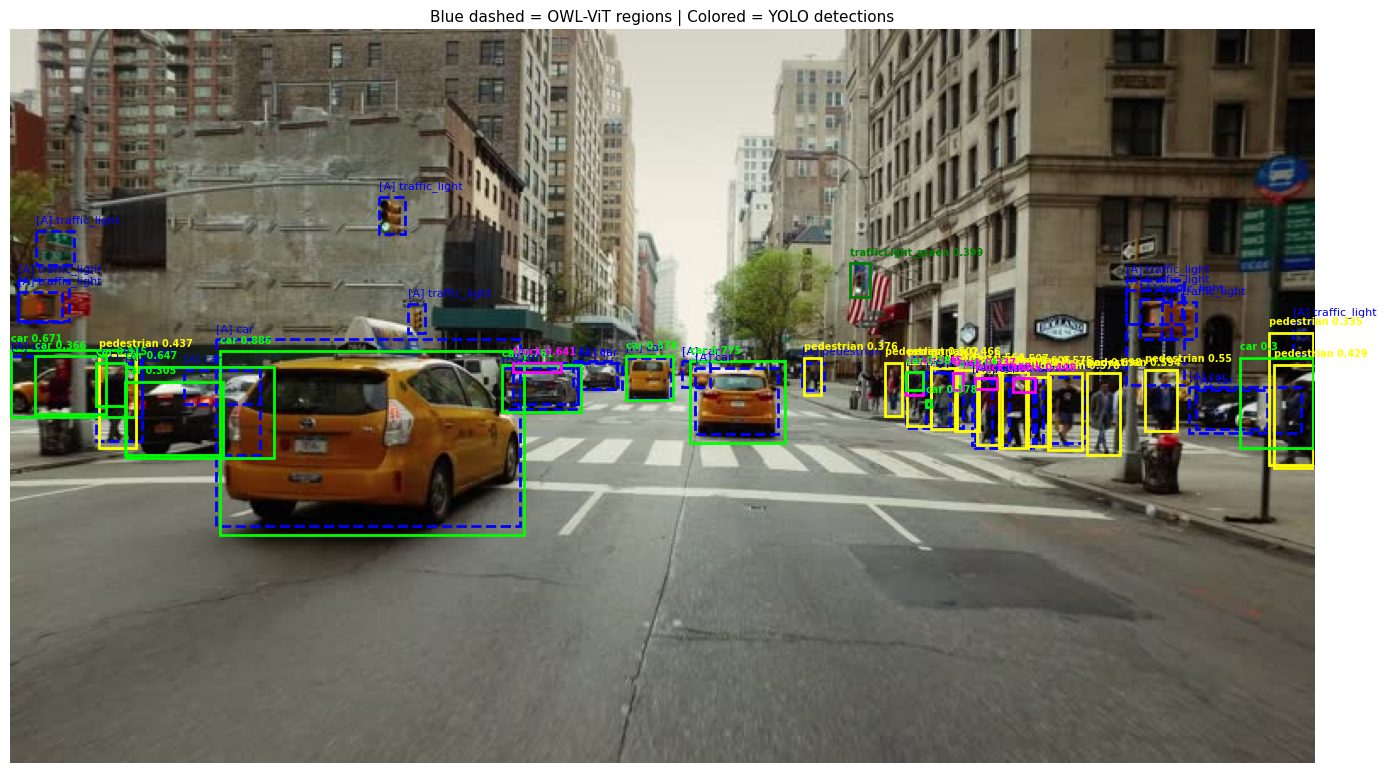

In [55]:
visualize(image_filename, regions, detections)

14.1. Only YOLO Visualisation

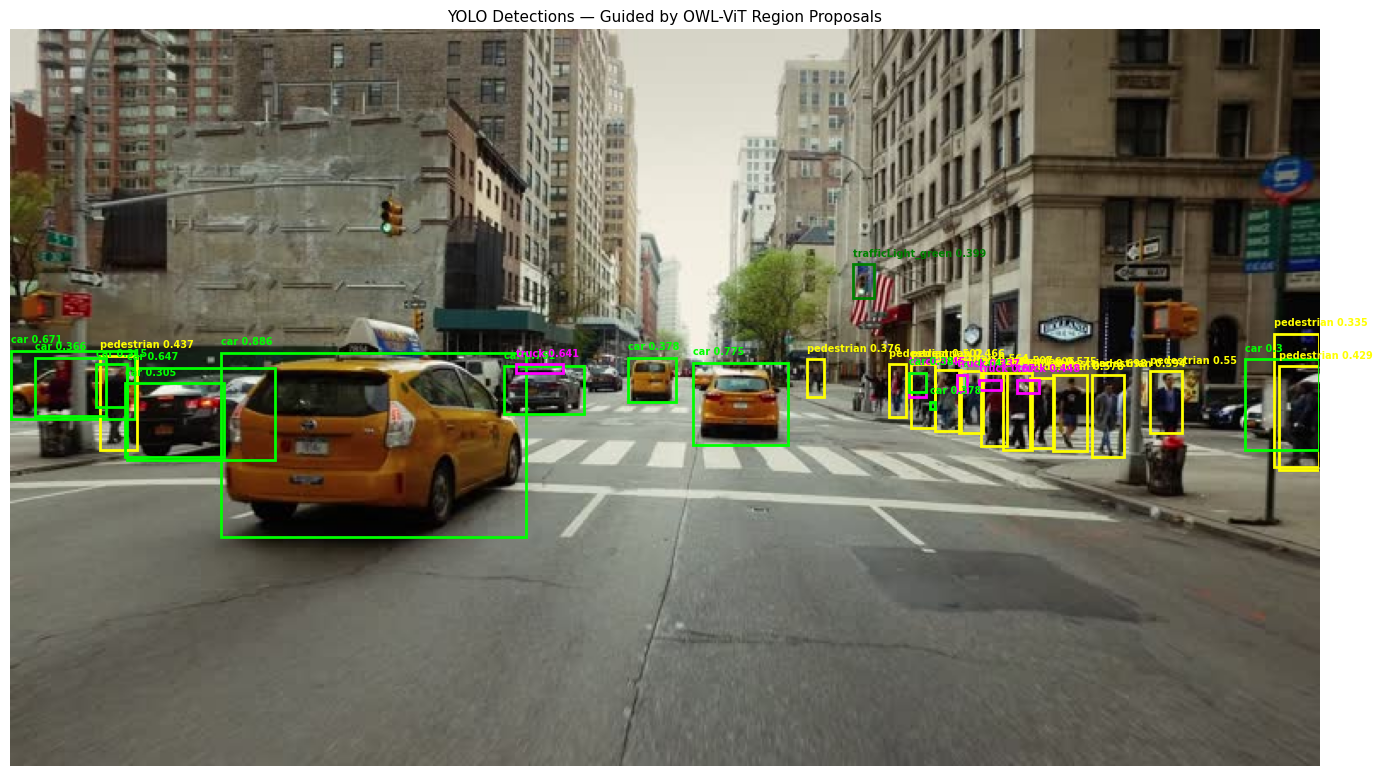

In [56]:
visualize_only_YOLO(image_filename, detections)